In [18]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/rmisra/news-category-dataset/News_Category_Dataset_v3.json


In [19]:
df = pd.read_json('/kaggle/input/datasets/rmisra/news-category-dataset/News_Category_Dataset_v3.json', lines=True)
df.sample()

,link,headline,category,short_description,authors,date
128310,https://www.huffingtonpost.com/entry/what-if-w...,What If We Were All Family Generation Changers?,IMPACT,"What if, in doing so, we won't just create new...","Matt Murrie, ContributorEdupreneur, Cofounder/...",2014-06-20


In [29]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import seaborn as sns
import matplotlib.pyplot as plt
import shutil
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from transformers import (
    DistilBertTokenizer, DistilBertForSequenceClassification,
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments, EarlyStoppingCallback
)
from torch.nn import CrossEntropyLoss
import warnings
warnings.filterwarnings('ignore')

In [21]:
df = df[['headline', 'category', 'short_description']]
df.head()

,headline,category,short_description
0,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...
1,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...
2,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha..."
3,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to..."
4,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...


In [22]:
# Preprocessing
df['headline'] = df['headline'].str.lower().str.replace(r'[^\w\s]', '', regex=True)
df['short_description'] = df['short_description'].str.lower().str.replace(r'[^\w\s]', '', regex=True)
df['full_text'] = df['headline'] + " " + df['short_description']
df['full_text'] = df['full_text'].str.replace(r'\b\d+\b', '', regex=True)
df['full_text'] = df['full_text'].str.replace(r'\s+', ' ', regex=True).str.strip()

df = df.dropna(subset=['full_text', 'category'])
df = df[df['full_text'] != '']

In [23]:
category_mapping = {
    "THE WORLDPOST": "WORLD NEWS", "WORLDPOST": "WORLD NEWS",
    "U.S. NEWS": "POLITICS", "PARENTS": "PARENTING",
    "ARTS": "ARTS & CULTURE", "CULTURE & ARTS": "ARTS & CULTURE",
    "STYLE": "STYLE & BEAUTY", "TASTE": "FOOD & DRINK", "HEALTHY LIVING": "WELLNESS",
    "COLLEGE": "EDUCATION", "BUSINESS": "MONEY", "WEIRD NEWS": "COMEDY",
    "LATINO VOICES": "QUEER VOICES", "MEDIA": "ENTERTAINMENT"
}
# Note: 'SCIENCE' and 'TECH' are kept separate as they hold distinct semantic contexts for BERT.
df['category'] = df['category'].replace(category_mapping)

target_categories = [
    "DIVORCE", "STYLE & BEAUTY", "FOOD & DRINK", "WEDDINGS", "POLITICS",
    "HOME & LIVING", "WELLNESS", "SPORTS", "QUEER VOICES", "PARENTING",
    "WORLD NEWS", "ENTERTAINMENT", "TRAVEL", "CRIME", "MONEY"
]
df_final = df[df['category'].isin(target_categories)].copy()

print(f"TOTAL High-Quality News for Training: {len(df_final)}")
print(f"Net Target Category Count: {len(target_categories)}")

TOTAL High-Quality News for Training: 169873
Net Target Category Count: 15


In [24]:
# Preparing Labels
encoder = LabelEncoder()
df_final['label'] = encoder.fit_transform(df_final['category'])
num_categories = len(encoder.classes_)

X_train, X_test, y_train, y_test = train_test_split(
    df_final['full_text'].tolist(),
    df_final['label'].tolist(),
    test_size=0.1,
    random_state=42
)

# Compute class weights to heavily penalize misclassifications in minority classes 
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
weights_tensor = torch.tensor(class_weights, dtype=torch.float)
print(f"Class weights calculated. Min: {weights_tensor.min():.2f}, Max: {weights_tensor.max():.2f}")

Class weights calculated. Min: 0.31, Max: 3.32


In [25]:
# ── PyTorch Dataset ───────────────────────────────────────────────────────────
class NewsDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [26]:
# ── Shared helpers ────────────────────────────────────────────────────────────
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "f1":       f1_score(labels, preds, average='weighted'),
        "accuracy": float((preds == labels).mean())
    }

class WeightedTrainer(Trainer):
    """Injects balanced class weights into CrossEntropyLoss."""
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.get("labels")
        outputs = model(**inputs)
        logits  = outputs.get("logits")
        loss_fn = CrossEntropyLoss(weight=weights_tensor.to(labels.device))
        loss    = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

In [43]:
# ── 1. DistilBERT ─────────────────────────────────────────────────────────────
DISTILBERT_DIR = './best_distilbert'

tokenizer_distil = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
train_enc_distil  = tokenizer_distil(X_train, truncation=True, padding=True, max_length=128)
test_enc_distil   = tokenizer_distil(X_test,  truncation=True, padding=True, max_length=128)

train_ds_distil = NewsDataset(train_enc_distil, y_train)
test_ds_distil  = NewsDataset(test_enc_distil,  y_test)

model_distilbert = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=num_categories
)

args_distil = TrainingArguments(
    output_dir            = './distilbert_tmp',   # temp checkpoints only
    num_train_epochs      = 4,
    per_device_train_batch_size = 32,
    per_device_eval_batch_size  = 64,
    eval_strategy         = 'steps',
    eval_steps            = 1000,
    save_strategy         = 'steps',
    save_steps            = 1000,
    save_total_limit      = 1,                    # keep only 1 checkpoint at a time
    fp16                  = True,
    logging_dir           = './distilbert_logs',
    load_best_model_at_end= True,
    weight_decay          = 0.01,
    learning_rate         = 3e-5,
    warmup_ratio          = 0.1,
    metric_for_best_model = 'f1',
    greater_is_better     = True,
)

trainer_distil = WeightedTrainer(
    model          = model_distilbert,
    args           = args_distil,
    train_dataset  = train_ds_distil,
    eval_dataset   = test_ds_distil,
    compute_metrics= compute_metrics,
    callbacks      = [EarlyStoppingCallback(early_stopping_patience=3)],
)

print("Training DistilBERT...")
trainer_distil.train()

# Save only the best model weights — remove temp checkpoints afterward
trainer_distil.save_model(DISTILBERT_DIR)
tokenizer_distil.save_pretrained(DISTILBERT_DIR)
if os.path.exists('./distilbert_tmp'):
    shutil.rmtree('./distilbert_tmp')
print(f"DistilBERT best model saved → {DISTILBERT_DIR}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

DistilBERT best model saved → ./best_distilbert


In [42]:
# ── RoBERTa-base ───────────────────────────────────────────────────────────────
ROBERTA_DIR = './best_roberta'

MODEL_NAME = "roberta-base"

tokenizer_roberta = AutoTokenizer.from_pretrained(MODEL_NAME)

train_enc_roberta = tokenizer_roberta(
    X_train,
    truncation=True,
    padding=True,
    max_length=128
)

test_enc_roberta = tokenizer_roberta(
    X_test,
    truncation=True,
    padding=True,
    max_length=128
)

train_ds_roberta = NewsDataset(train_enc_roberta, y_train)
test_ds_roberta  = NewsDataset(test_enc_roberta,  y_test)

model_roberta = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_categories
)

# model_roberta.to(device)

args_roberta = TrainingArguments(
    output_dir='./roberta_tmp',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,

    eval_strategy='epoch',
    save_strategy='epoch',
    save_total_limit=1,

    fp16=True,

    logging_dir='./roberta_logs',
    logging_steps=50,
    report_to="tensorboard",

    load_best_model_at_end=True,
    weight_decay=0.01,
    learning_rate=1e-5,
    warmup_ratio=0.1,

    metric_for_best_model='f1',
    greater_is_better=True,
)

trainer_roberta = WeightedTrainer(
    model=model_roberta,
    args=args_roberta,
    train_dataset=train_ds_roberta,
    eval_dataset=test_ds_roberta,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

print("Training RoBERTa-base...")
trainer_roberta.train()

trainer_roberta.save_model(ROBERTA_DIR)
tokenizer_roberta.save_pretrained(ROBERTA_DIR)

if os.path.exists('./roberta_tmp'):
    shutil.rmtree('./roberta_tmp')

print(f"RoBERTa best model saved → {ROBERTA_DIR}")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated 

Training RoBERTa-base...


Epoch,Training Loss,Validation Loss,F1,Accuracy
1,0.641313,0.581697,0.800547,0.797798
2,0.549349,0.533350,0.819390,0.817636
3,0.496149,0.529546,0.825598,0.824052


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

RoBERTa best model saved → ./best_roberta


In [44]:
# ── 3. Individual evaluation ──────────────────────────────────────────────────
def get_probabilities(trainer, dataset):
    """Return softmax probabilities from a trained Trainer."""
    result = trainer.predict(dataset)
    logits = torch.tensor(result.predictions)
    probs  = torch.softmax(logits, dim=-1).numpy()
    return probs, result.label_ids

probs_distil,  true_labels = get_probabilities(trainer_distil,  test_ds_distil)
probs_roberta, _           = get_probabilities(trainer_roberta, test_ds_roberta)

preds_distil  = np.argmax(probs_distil,  axis=1)
preds_roberta = np.argmax(probs_roberta, axis=1)

acc_distil  = accuracy_score(true_labels, preds_distil)
acc_roberta = accuracy_score(true_labels, preds_roberta)

f1_distil   = f1_score(true_labels, preds_distil,  average='weighted')
f1_roberta  = f1_score(true_labels, preds_roberta, average='weighted')

print(f"{'Model':<22} {'Accuracy':>10} {'Weighted F1':>13}")
print("-" * 47)
print(f"{'DistilBERT':<22} {acc_distil:>10.4f} {f1_distil:>13.4f}")
print(f"{'RoBERTa-base':<22} {acc_roberta:>10.4f} {f1_roberta:>13.4f}")

Model                    Accuracy   Weighted F1
-----------------------------------------------
DistilBERT                 0.8231        0.8247
RoBERTa-base               0.8241        0.8256


In [45]:
# ── 4. Ensemble — soft voting & weighted averaging ────────────────────────────

# 4a. Equal-weight soft voting (average of probabilities)
probs_soft = (probs_distil + probs_roberta) / 2
preds_soft = np.argmax(probs_soft, axis=1)

acc_soft = accuracy_score(true_labels, preds_soft)
f1_soft  = f1_score(true_labels, preds_soft, average='weighted')

# 4b. Weighted average — weight each model by its individual F1
w_distil  = f1_distil  / (f1_distil + f1_roberta)
w_roberta = f1_roberta / (f1_distil + f1_roberta)

probs_weighted = w_distil * probs_distil + w_roberta * probs_roberta
preds_weighted = np.argmax(probs_weighted, axis=1)

acc_weighted = accuracy_score(true_labels, preds_weighted)
f1_weighted  = f1_score(true_labels, preds_weighted, average='weighted')

print(f"{'Model':<30} {'Accuracy':>10} {'Weighted F1':>13}")
print("-" * 55)
print(f"{'DistilBERT':<30} {acc_distil:>10.4f} {f1_distil:>13.4f}")
print(f"{'RoBERTa-base':<30} {acc_roberta:>10.4f} {f1_roberta:>13.4f}")
print(f"{'Ensemble — soft voting':<30} {acc_soft:>10.4f} {f1_soft:>13.4f}")
print(f"{'Ensemble — weighted avg':<30} {acc_weighted:>10.4f} {f1_weighted:>13.4f}")

print(f"\nEnsemble weights → DistilBERT: {w_distil:.3f}  |  RoBERTa: {w_roberta:.3f}")

Model                            Accuracy   Weighted F1
-------------------------------------------------------
DistilBERT                         0.8231        0.8247
RoBERTa-base                       0.8241        0.8256
Ensemble — soft voting             0.8375        0.8388
Ensemble — weighted avg            0.8376        0.8389

Ensemble weights → DistilBERT: 0.500  |  RoBERTa: 0.500


In [46]:
# ── 5. Pick the best overall model ───────────────────────────────────────────
scores = {
    'DistilBERT':              (acc_distil,    f1_distil,    preds_distil),
    'RoBERTa-base':            (acc_roberta,   f1_roberta,   preds_roberta),
    'Ensemble — soft voting':  (acc_soft,      f1_soft,      preds_soft),
    'Ensemble — weighted avg': (acc_weighted,  f1_weighted,  preds_weighted),
}

best_name = max(scores, key=lambda k: scores[k][1])   # rank by weighted F1
best_acc, best_f1, best_preds = scores[best_name]

print(f"\n🏆  Best model: {best_name}")
print(f"    Accuracy  : {best_acc:.4f}")
print(f"    Weighted F1: {best_f1:.4f}")


🏆  Best model: Ensemble — weighted avg
    Accuracy  : 0.8376
    Weighted F1: 0.8389



── Classification Report: Ensemble — weighted avg ──
                precision    recall  f1-score   support

         CRIME       0.63      0.85      0.72       374
       DIVORCE       0.82      0.83      0.83       355
 ENTERTAINMENT       0.83      0.84      0.83      1967
  FOOD & DRINK       0.85      0.90      0.88       791
 HOME & LIVING       0.84      0.86      0.85       440
         MONEY       0.66      0.74      0.70       765
     PARENTING       0.80      0.87      0.83      1272
      POLITICS       0.92      0.79      0.85      3733
  QUEER VOICES       0.74      0.80      0.77       748
        SPORTS       0.77      0.88      0.82       464
STYLE & BEAUTY       0.89      0.89      0.89      1207
        TRAVEL       0.90      0.90      0.90       996
      WEDDINGS       0.84      0.89      0.87       372
      WELLNESS       0.89      0.83      0.86      2536
    WORLD NEWS       0.76      0.88      0.81       968

      accuracy                           0.84   

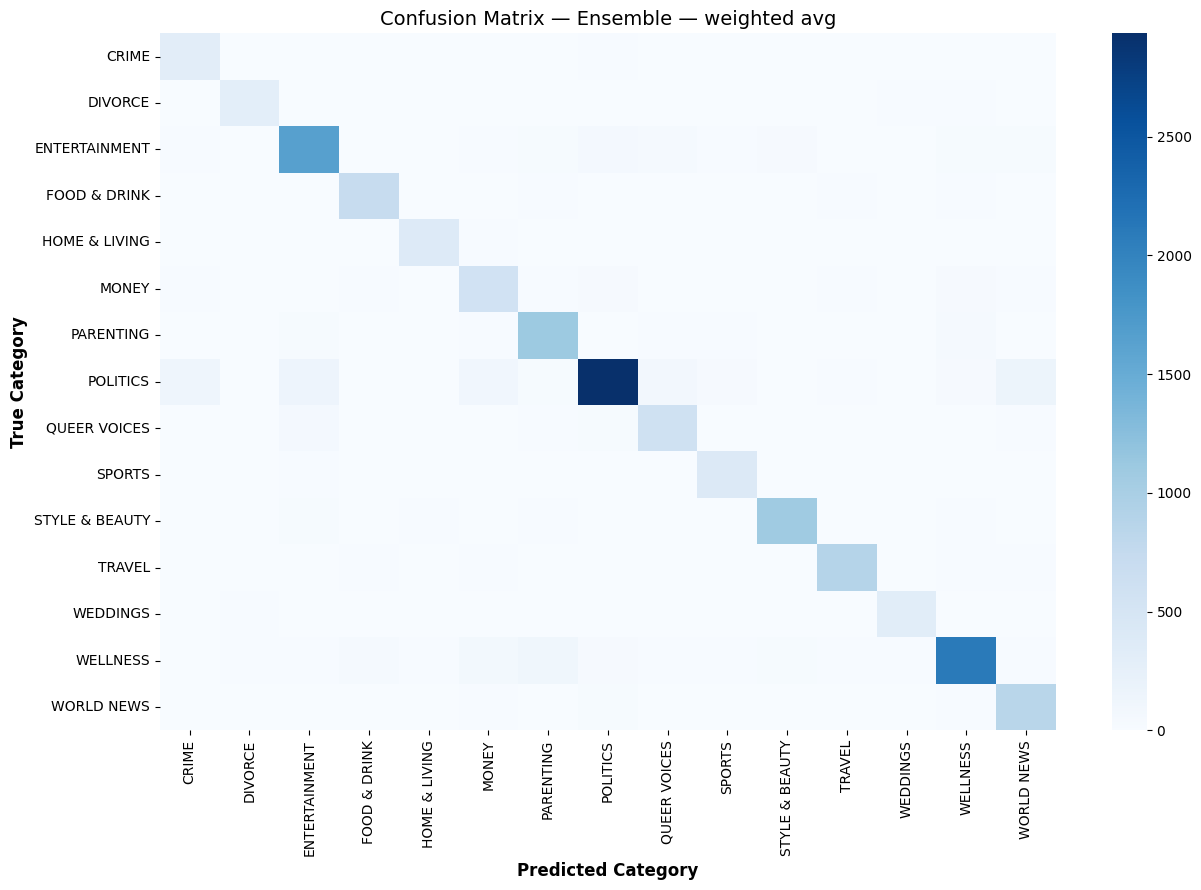

In [47]:
# ── 6. Detailed report for the best model ─────────────────────────────────────
category_names = encoder.classes_

print(f"\n── Classification Report: {best_name} ──")
print(classification_report(true_labels, best_preds, target_names=category_names))

cm = confusion_matrix(true_labels, best_preds)
plt.figure(figsize=(13, 9))
sns.heatmap(cm, annot=False, cmap='Blues',
            xticklabels=category_names, yticklabels=category_names)
plt.xlabel('Predicted Category', fontsize=12, fontweight='bold')
plt.ylabel('True Category',      fontsize=12, fontweight='bold')
plt.title(f'Confusion Matrix — {best_name}', fontsize=14)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

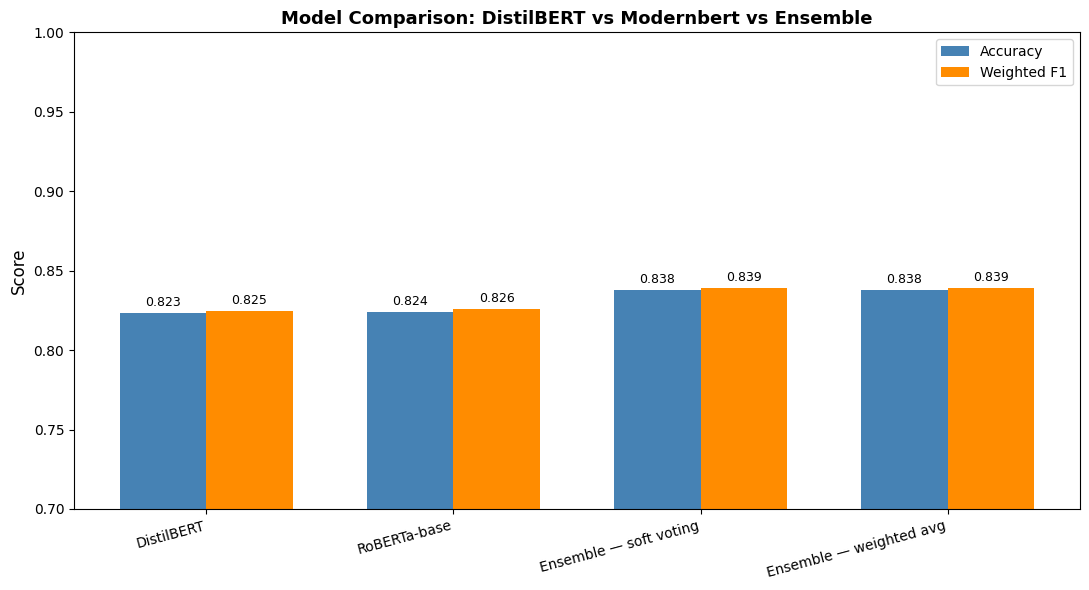

In [48]:
# ── 7. Side-by-side comparison bar chart ─────────────────────────────────────
model_names  = list(scores.keys())
accuracies   = [scores[m][0] for m in model_names]
f1_scores_all= [scores[m][1] for m in model_names]

x     = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
bars1 = ax.bar(x - width/2, accuracies,    width, label='Accuracy',    color='steelblue')
bars2 = ax.bar(x + width/2, f1_scores_all, width, label='Weighted F1', color='darkorange')

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison: DistilBERT vs Modernbert vs Ensemble', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.set_ylim(0.7, 1.0)
ax.legend()
ax.bar_label(bars1, fmt='%.3f', padding=3, fontsize=9)
ax.bar_label(bars2, fmt='%.3f', padding=3, fontsize=9)
plt.tight_layout()
plt.show()

In [50]:
import shutil

shutil.make_archive('distilbert_model_Zip', 'zip', 'best_distilbert')

'/kaggle/working/distilbert_model_Zip.zip'

In [51]:
shutil.make_archive('roberta_model_Zip', 'zip', 'best_roberta')

'/kaggle/working/roberta_model_Zip.zip'